# Proyecto Phoenix: Detección de Fraude en E-Commerce
## IEEE-CIS Fraud Detection Challenge
### Grupo 2

**Equipo**: Diego Alejandro Irreño - David Fernando Lopez - Juan Camilo López - Edda Camila Rodriguez.


**Objetivo**: El propósito es construir un modelo predictivo de detección de fraude en transacciones de comercio electrónico utilizando técnicas de *Machine Learning*. Se busca identificar transacciones fraudulentas con alta precisión para proteger tanto a comerciantes como a consumidores en el ecosistema de pagos digitales.

**Origen de los Datos**: [Datos Vesta Corporation](https://www.kaggle.com/competitions/ieee-fraud-detection/data)

**Dataset**: 590,540 transacciones con 434 variables  
**Desbalance**: 3.5% fraude, 96.5% legítimo



**Nota**: Nos apoyamos con herramientas IA: Copilot, GPT, Gemini para generación de código y corrección de errores y mejora de redacción. 
**Estructura:** Es un dataset de escala industrial compuesto por dos tablas principales: **Transacciones** (datos de pago, montos y variables anonimizadas) e **Identidad** (contexto del dispositivo y red), conectadas por el `TransactionID`.

**Volumen:** Contiene un total de **590,540 registros** y **434 variables**.

**Desafío técnico:** Presenta un alto desbalance, donde solo el **3.5%** de las transacciones son fraudulentas.

**Métrica principal:** El modelo se optimiza utilizando el **AUC-ROC** (Área bajo la curva de la característica operativa del receptor). Esta métrica es fundamental en este contexto porque permite evaluar el rendimiento del modelo en datos asimétricos o desbalanceados, donde la exactitud simple no es confiable.

El notebook presenta el siguiente orden, lo que permite obtener conclusiones a partir de la exploración inicial, limpieza, ingeniería de características y comparación de varios modelos.

1. Carga de datos
2. Análisis exploratorio (EDA)
3. Feature engineering
4. Limpieza de datos
5. Modelado
6.  Explicabilidad y Curvas de Pérdida

### 1. Carga de datos

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from datetime import datetime
import warnings
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')

In [38]:
data_path = Path('./ieee-fraud-detection')

print("cargando data")
train_transaction = pd.read_csv(data_path / 'train_transaction.csv')
train_identity = pd.read_csv(data_path / 'train_identity.csv')
test_transaction = pd.read_csv(data_path / 'test_transaction.csv')
test_identity = pd.read_csv(data_path / 'test_identity.csv')

print(f"train_transaction: {train_transaction.shape}")
print(f"train_identity: {train_identity.shape}")
print(f"test_transaction: {test_transaction.shape}")
print(f"test_identity: {test_identity.shape}")

cargando data
train_transaction: (590540, 394)
train_identity: (144233, 41)
test_transaction: (506691, 393)
test_identity: (141907, 41)


In [39]:
print("Uniendo data")
train_data = train_transaction.merge(train_identity, on='TransactionID', how='left')
test_data = test_transaction.merge(test_identity, on='TransactionID', how='left')

print(f"filas con información de identity: {train_data['id_01'].notna().sum()} / {len(train_data)}")


print(f"train_data: {train_data.shape}")
print(f"test_data: {test_data.shape}")

Uniendo data
filas con información de identity: 144233 / 590540
train_data: (590540, 434)
test_data: (506691, 433)


### 2. Análisis exploratorio (EDA)

Desbalance de clases

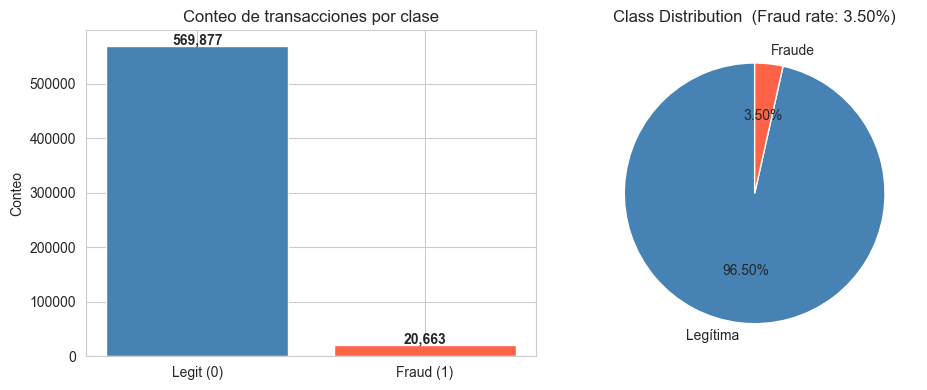

In [40]:
counts = train_data['isFraud'].value_counts()
fraud_rate = counts[1] / len(train_data) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Legit (0)', 'Fraud (1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Conteo de transacciones por clase')
axes[0].set_ylabel('Conteo')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Legítima', 'Fraude'], autopct='%1.2f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title(f'Class Distribution  (Fraud rate: {fraud_rate:.2f}%)')

plt.tight_layout()
plt.show()

Volumen transacciones en serie de tiempo

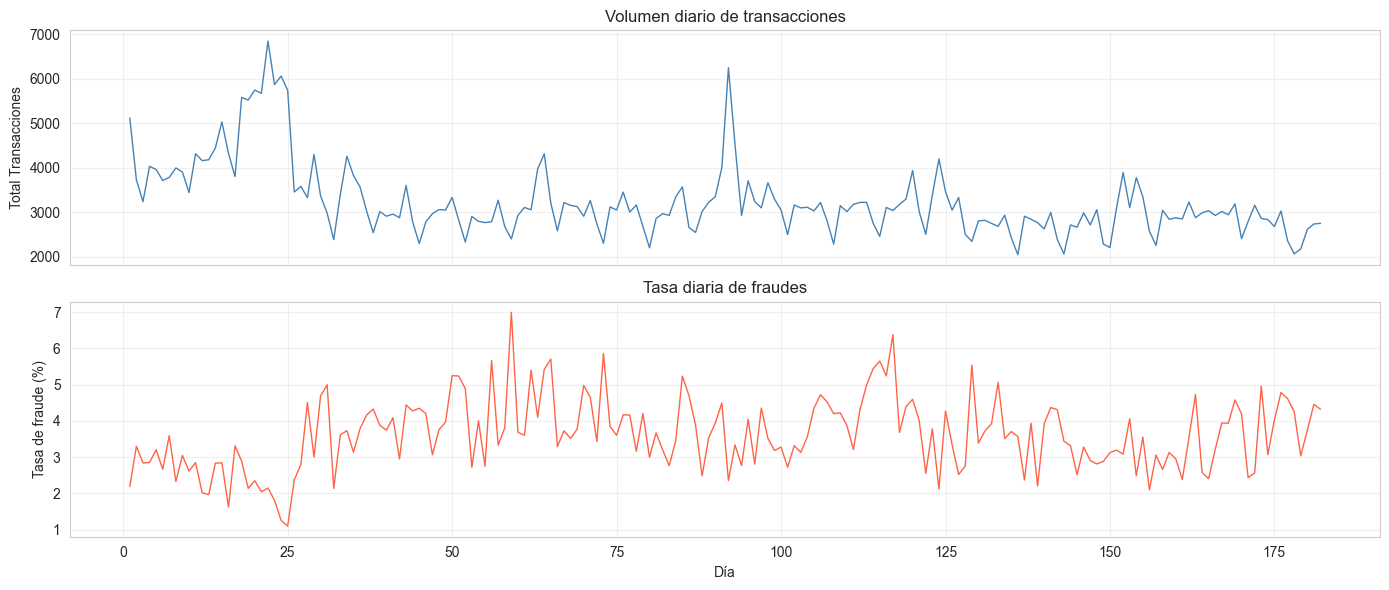

In [6]:
daily = train_data.groupby(train_data['TransactionDT'] // 86400)['isFraud'].agg(['count', 'sum'])
daily.columns = ['total', 'fraud']

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(daily.index, daily['total'], color='steelblue', linewidth=1)
axes[0].set_ylabel('Total Transacciones')
axes[0].set_title('Volumen diario de transacciones')
axes[0].grid(alpha=0.3)

axes[1].plot(daily.index, daily['fraud'] / daily['total'] * 100, color='tomato', linewidth=1)
axes[1].set_ylabel('Tasa de fraude (%)')
axes[1].set_xlabel('Día')
axes[1].set_title('Tasa diaria de fraudes')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Nulos

Columns with missing values: 414 / 434


,Count
0-10%,92
10-50%,108
50-90%,202
90-100%,12


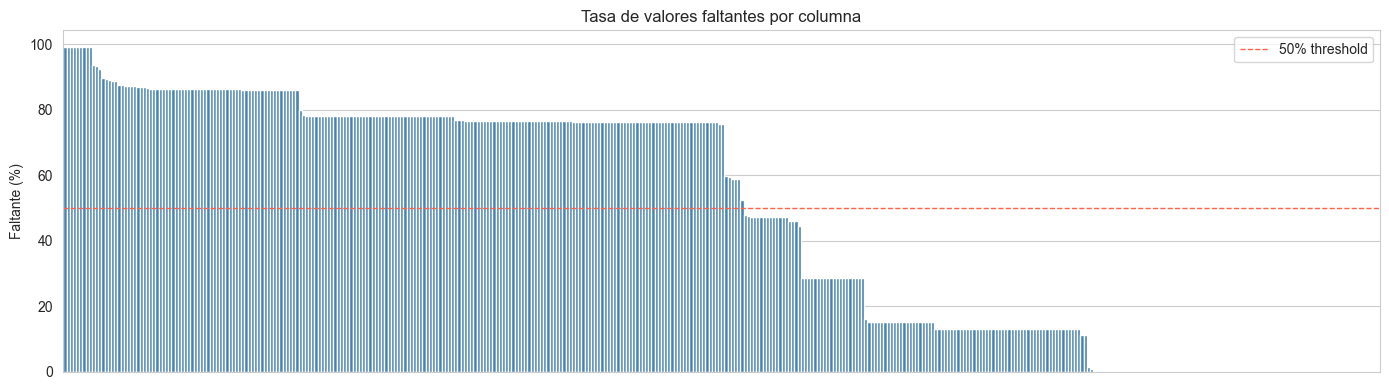

In [41]:
missing = (train_data.isnull().mean() * 100).sort_values(ascending=False)
missing_nonzero = missing[missing > 0]

print(f"Columns with missing values: {len(missing_nonzero)} / {train_data.shape[1]}")

bins = [0, 10, 50, 90, 100]
labels = ['0-10%', '10-50%', '50-90%', '90-100%']

missing_binned = pd.cut(missing_nonzero, bins=bins, labels=labels, include_lowest=True)
result = missing_binned.value_counts().sort_index()
display(result.to_frame(name='Count').style.set_caption('Distribución de valores faltantes (%)'))

fig, ax = plt.subplots(figsize=(14, 4))
missing_nonzero.plot(kind='bar', ax=ax, color='steelblue', width=1.0)
ax.axhline(50, color='tomato', linestyle='--', linewidth=1, label='50% threshold')
ax.set_title('Tasa de valores faltantes por columna')
ax.set_ylabel('Faltante (%)')
ax.set_xticks([])
ax.legend()
plt.tight_layout()
plt.show()

Fraude por variable categórica (top 4)

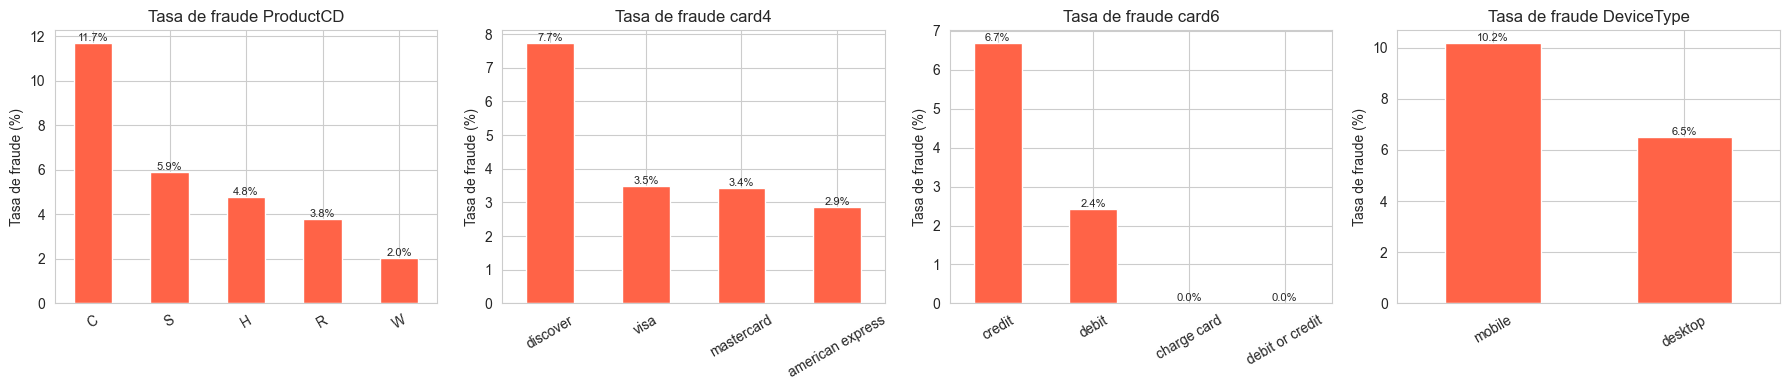

In [42]:
cat_cols = ['ProductCD', 'card4', 'card6', 'DeviceType']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, cat_cols):
    fraud_rate_col = train_data.groupby(col)['isFraud'].mean().sort_values(ascending=False) * 100
    fraud_rate_col.plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
    ax.set_title(f'Tasa de fraude {col}')
    ax.set_ylabel('Tasa de fraude (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Correlación de variables con fraude

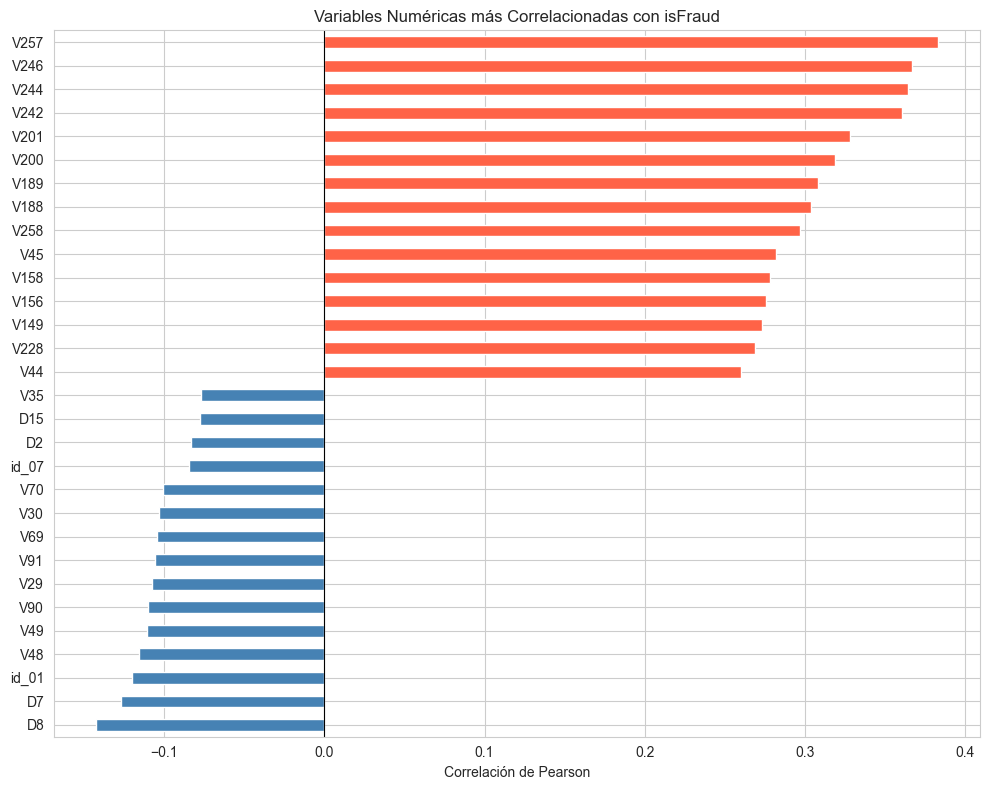

,Correlación con isFraud
V257,0.3831
V246,0.3669
V244,0.3641
V242,0.3606
V201,0.3280
V200,0.3188
V189,0.3082
V188,0.3036
V258,0.2972
V45,0.2818


In [ ]:
exclude_cols = ['TransactionID', 'TransactionDT', 'isFraud']

num_cols = (
    train_data
    .select_dtypes(include='number')
    .columns
    .drop([col for col in exclude_cols if col in train_data.columns])
)

corr = train_data[num_cols].corrwith(train_data['isFraud']).dropna()

top_corr = pd.concat([
    corr.nlargest(15),
    corr.nsmallest(15)
]).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['tomato' if value > 0 else 'steelblue' for value in top_corr.values]

top_corr.plot(
    kind='barh',
    ax=ax,
    color=colors
)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Variables Numéricas más Correlacionadas con isFraud')
ax.set_xlabel('Correlación de Pearson')

plt.tight_layout()
plt.show()

display(
    top_corr
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .to_frame('Correlación con isFraud')
    .round(4)
)


Colinealidad de variables - proceso de eliminación

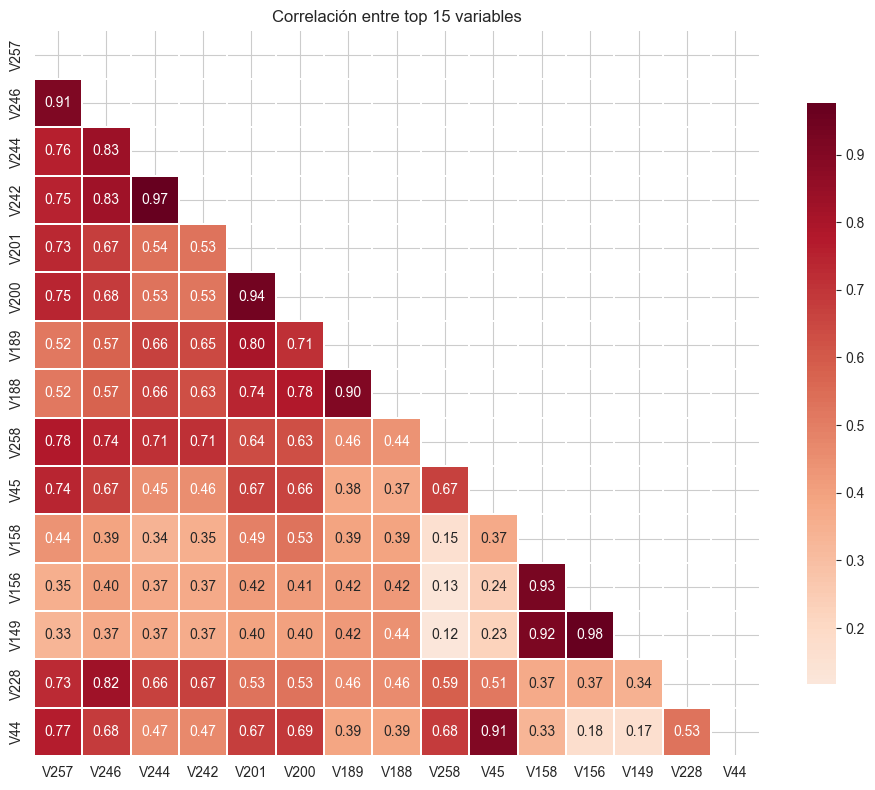

In [44]:
top_vars = top_corr.abs().nlargest(15).index
corr_matrix = train_data[top_vars].corr().fillna(0)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', linewidths=0.3,
            square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlación entre top 15 variables')
plt.tight_layout()
plt.show()

In [45]:
exclude_cols = ['TransactionID', 'TransactionDT', 'isFraud']

num_cols = (
    train_data
    .select_dtypes(include='number')
    .columns
    .drop([col for col in exclude_cols if col in train_data.columns])
)

# pares de alta correlación (|r| > 0.7) 
cor_matrix  = train_data[num_cols].corr()
mask        = np.triu(np.ones_like(cor_matrix, dtype=bool), k=1)
threshold   = 0.7
high_corr_mask = (cor_matrix.abs() > threshold) & mask
rows, cols  = np.where(high_corr_mask)

high_corr_df = (
    pd.DataFrame({
        'var1': cor_matrix.index[rows],
        'var2': cor_matrix.columns[cols],
        'corr': cor_matrix.to_numpy()[rows, cols]
    })
    .assign(abs_corr=lambda x: x['corr'].abs())
    .sort_values('abs_corr', ascending=False)
    .drop(columns='abs_corr')
    .reset_index(drop=True)
)

print(f"Pares con |correlación| > {threshold}: {len(high_corr_df)}")

# greedy drop: de cada par, eliminar el menos correlacionado con isFraud
corr_target = train_data[num_cols].corrwith(train_data['isFraud']).abs()
to_drop = []
for _, row in high_corr_df.iterrows():
    if row['var1'] not in to_drop and row['var2'] not in to_drop:
        if corr_target.get(row['var1'], 0) >= corr_target.get(row['var2'], 0):
            to_drop.append(row['var2'])
        else:
            to_drop.append(row['var1'])

print(f"Variables candidatas a eliminar: {len(set(to_drop))}")
display(pd.DataFrame({'candidate_to_drop': sorted(set(to_drop))}))

Pares con |correlación| > 0.7: 3754
Variables candidatas a eliminar: 287


,candidate_to_drop
0,C1
1,C10
2,C11
3,C12
4,C13
...,...
282,V98
283,V99
284,addr2
285,id_09


Este proceso es el más simple y justificable para reducir la dimensionalidad sin pérdida de información relevante. 
Ante la presencia de 3754 pares de variables con correlación superior a 0.7, mantener todas implicaría redundancia 
computacional y posible inestabilidad en los modelos. La estrategia greedy resuelve esto con un criterio claro: 
ante dos variables que dicen lo mismo, se conserva la que tiene mayor relación con el fraude y se descarta la otra. 
A diferencia de métodos como PCA, este enfoque preserva la interpretabilidad y las variables que quedan son las 
originales del dataset, no combinaciones lineales abstractas.

### 3. Ingeniería de Características


Preparación base del Feature Engineering

Este bloque deja `train` y `test` listos para crear variables nuevas de forma consistente. Primero se modifican nombres de columnas cambiando guiones por guiones bajos, separa `isFraud` como variable objetivo y trabaja sobre copias (`X_train_fe`, `X_test_fe`) para no perder los datos originales. ademas harmonizamos las variables de test.

In [46]:
test_data = test_data.rename(columns=lambda col: col.replace('-', '_'))

y_train = train_data['isFraud'].copy()

common_cols = [c for c in test_data.columns if c in train_data.columns and c != 'isFraud']

X_train_fe = train_data[common_cols].copy()

X_test_fe = test_data[common_cols].copy()

print("Columnas alineadas (recortadas a columnas de test):")
print("X_train_fe:", X_train_fe.shape)
print("X_test_fe: ", X_test_fe.shape)

Columnas alineadas (recortadas a columnas de test):
X_train_fe: (590540, 433)
X_test_fe:  (506691, 433)


Funciones auxiliares para crear features reutilizables

Aquí se definen tres funciones que se usarán en varios pasos de la Fase 3. `frequency_encode` convierte categorías en frecuencias relativas usando `train + test` sin usar `isFraud`, por lo que no introduce leakage del target. Se utiliza esta forma de frequency encoding acá porque muchas variables del dataset son categóricas con muchísimos valores posibles: tarjetas, direcciones, dominios de correo, dispositivos e identificadores. Si se usara one-hot encoding, se crearían demasiadas columnas y el modelo se volvería más pesado y ruidoso.

In [13]:
def frequency_encode(train_df, test_df, cols):
    for col in cols:

        combined = pd.concat([train_df[col], test_df[col]], axis=0)
        freq_map = combined.value_counts(dropna=False, normalize=True).to_dict()

        new_col = f'{col}_FE'

        train_df[new_col] = train_df[col].map(freq_map).astype('float32')
        test_df[new_col] = test_df[col].map(freq_map).astype('float32')


        print(new_col, end=', ')

`combine_columns` construye identificadores sintéticos tipo UID combinando variables como tarjeta, dirección y dominio de correo.

In [14]:
def combine_columns(train_df, test_df, col1, col2):
    
    new_col = f'{col1}_{col2}'

    train_df[new_col] = (
        train_df[col1].astype(str) + '_' + train_df[col2].astype(str)
    )

    test_df[new_col] = (
        test_df[col1].astype(str) + '_' + test_df[col2].astype(str)
    )

    print(new_col, end=', ')
    return new_col

`group_aggregate` se usa porque ayuda al modelo a entender si una transacción  es normal o anomala, en detección de fraude no basta con saber el valor absoluto de una transacción; también importa el contexto. Las agregaciones por grupo permiten capturar patrones normales de cada usuario y detectar desviaciones que pueden indicar fraude.

In [15]:
def group_aggregate(train_df, test_df, main_cols, group_cols, aggs=['mean', 'std']):
    for main_col in main_cols:

        for group_col in group_cols:
            if group_col not in train_df.columns or group_col not in test_df.columns:
                continue

            temp = pd.concat(
                [
                    train_df[[group_col, main_col]],
                    test_df[[group_col, main_col]]
                ],
                axis=0
            )

            for agg in aggs:
                new_col = f'{main_col}_{group_col}_{agg}'

                agg_map = temp.groupby(group_col)[main_col].agg(agg).to_dict()

                train_df[new_col] = train_df[group_col].map(agg_map).astype('float32')
                test_df[new_col] = test_df[group_col].map(agg_map).astype('float32')

                train_df[new_col] = train_df[new_col].fillna(-1)
                test_df[new_col] = test_df[new_col].fillna(-1)

                print(new_col, end=', ')

`group_nunique` calcula estadísticas por grupo para capturar comportamiento típico, variabilidad y consistencia de cada usuario o tarjeta. Si hay demasiada variedad dentro de una misma identidad aproximada, eso puede ser señal de riesgo.Se usa para medir qué tan variable o inconsistente es el comportamiento dentro de un grupo. Asi, la idea es responder estas preguntas:

* Para una misma tarjeta, ¿cuántas direcciones distintas aparecen?
* Para una misma tarjeta + dirección, ¿cuántos dominios de correo distintos aparecen?
* Para un mismo UID, ¿cuántos montos diferentes se han usado?


Las funciones anteriores se plantearon dado que en una versión inicial el feature engineering que se genero manualmente resulto  simple y quedaban muchas variables, por lo que se hicieron lecturas de los notebooks de la competencia y se observaron manejos más interesantes e impactantes para los procesos de detección de Fraude. 

Señalamos algunas fuentas de información que ayudaron a mejorar este ejercicio de ingeniería de características: 

* https://www.kaggle.com/code/cdeotte/xgb-fraud-with-magic-0-9600#Feature-Engineering
* https://www.kaggle.com/code/kyakovlev/ieee-fe-with-some-eda

In [16]:
def group_nunique(train_df, test_df, main_cols, group_cols):
    for main_col in main_cols:
        if main_col not in train_df.columns or main_col not in test_df.columns:
            continue

        for group_col in group_cols:
            if group_col not in train_df.columns or group_col not in test_df.columns:
                continue

            temp = pd.concat(
                [
                    train_df[[group_col, main_col]],
                    test_df[[group_col, main_col]]
                ],
                axis=0
            )

            new_col = f'{group_col}_{main_col}_nunique'
            nunique_map = temp.groupby(group_col)[main_col].nunique().to_dict()

            train_df[new_col] = train_df[group_col].map(nunique_map).astype('float32')
            test_df[new_col] = test_df[group_col].map(nunique_map).astype('float32')

            train_df[new_col] = train_df[new_col].fillna(-1)
            test_df[new_col] = test_df[new_col].fillna(-1)

            print(new_col, end=', ')


Features de monto y tiempo

Este bloque crea variables interpretables a partir de `TransactionAmt` y `TransactionDT`. De monto se extraen los centavos (`TransactionAmt_cents`), útiles porque el fraude puede diferir entre montos redondos, montos con decimales y distribuciones muy sesgadas. De tiempo se derivan día, hora y día de la semana para capturar patrones temporales, como actividad sospechosa en ciertas horas o cambios por ciclos semanales.

In [47]:
print("Creando features de centavos")

if 'TransactionAmt' in X_train_fe.columns:
    for df_ in [X_train_fe, X_test_fe]:
        df_['TransactionAmt_cents'] = (
            df_['TransactionAmt'] - np.floor(df_['TransactionAmt'])
        ).astype('float32')


print("\nCreando features temporales")

if 'TransactionDT' in X_train_fe.columns:
    seconds_per_day = 24 * 60 * 60

    for df_ in [X_train_fe, X_test_fe]:
        df_['Transaction_day'] = (df_['TransactionDT'] // seconds_per_day).astype('int16')
        df_['Transaction_hour'] = ((df_['TransactionDT'] % seconds_per_day) // 3600).astype('int8')
        df_['Transaction_weekday'] = (df_['Transaction_day'] % 7).astype('int8')

print("Transaction_day, Transaction_hour, Transaction_weekday")


Creando features de centavos

Creando features temporales
Transaction_day, Transaction_hour, Transaction_weekday


#### Aplicación de funciones

Frequency encoding de variables categóricas base

In [48]:
print("Frequency encoding:")

freq_cols = [
    'addr1',
    'card1',
    'card2',
    'card3',
    'card5',
    'P_emaildomain',
    'DeviceInfo'
]

frequency_encode(X_train_fe, X_test_fe, freq_cols)


Frequency encoding:
addr1_FE, card1_FE, card2_FE, card3_FE, card5_FE, P_emaildomain_FE, DeviceInfo_FE, 

Combinaciones tipo UID


In [49]:
print("\n\nCreando combinaciones tipo UID:")

created_uid_cols = []

uid_1 = combine_columns(X_train_fe, X_test_fe, 'card1', 'card2')
created_uid_cols.append(uid_1)

uid_2 = combine_columns(X_train_fe, X_test_fe, 'card1_card2', 'addr1')
created_uid_cols.append(uid_2)

uid_3 = combine_columns(X_train_fe, X_test_fe, 'card1_card2_addr1', 'P_emaildomain')
created_uid_cols.append(uid_3)

print("UIDs creados:")
print(created_uid_cols)




Creando combinaciones tipo UID:
card1_card2, card1_card2_addr1, card1_card2_addr1_P_emaildomain, UIDs creados:
['card1_card2', 'card1_card2_addr1', 'card1_card2_addr1_P_emaildomain']


Frequency encoding de los UIDs creados


In [50]:
print("Frequency encoding de UIDs:")

frequency_encode(X_train_fe, X_test_fe, created_uid_cols)


Frequency encoding de UIDs:
card1_card2_FE, card1_card2_addr1_FE, card1_card2_addr1_P_emaildomain_FE, 

Agregaciones estadísticas por UID

In [51]:
print("\n\nAgregaciones por UID:")

main_agg_cols = [
    'TransactionAmt',
    'D1',
    'D4',
    'D9',
    'D10',
    'D11'
]

group_cols = [
    'card1',
    'card1_card2',
    'card1_card2_addr1',
    'card1_card2_addr1_P_emaildomain'
]

group_aggregate(
    X_train_fe,
    X_test_fe,
    main_cols=main_agg_cols,
    group_cols=group_cols,
    aggs=['mean', 'std']
)




Agregaciones por UID:
TransactionAmt_card1_mean, TransactionAmt_card1_std, TransactionAmt_card1_card2_mean, TransactionAmt_card1_card2_std, TransactionAmt_card1_card2_addr1_mean, TransactionAmt_card1_card2_addr1_std, TransactionAmt_card1_card2_addr1_P_emaildomain_mean, TransactionAmt_card1_card2_addr1_P_emaildomain_std, D1_card1_mean, D1_card1_std, D1_card1_card2_mean, D1_card1_card2_std, D1_card1_card2_addr1_mean, D1_card1_card2_addr1_std, D1_card1_card2_addr1_P_emaildomain_mean, D1_card1_card2_addr1_P_emaildomain_std, D4_card1_mean, D4_card1_std, D4_card1_card2_mean, D4_card1_card2_std, D4_card1_card2_addr1_mean, D4_card1_card2_addr1_std, D4_card1_card2_addr1_P_emaildomain_mean, D4_card1_card2_addr1_P_emaildomain_std, D9_card1_mean, D9_card1_std, D9_card1_card2_mean, D9_card1_card2_std, D9_card1_card2_addr1_mean, D9_card1_card2_addr1_std, D9_card1_card2_addr1_P_emaildomain_mean, D9_card1_card2_addr1_P_emaildomain_std, D10_card1_mean, D10_card1_std, D10_card1_card2_mean, D10_card1_c

Conteos únicos por grupo

In [52]:
print("\n\nConteos únicos por grupo:")

group_nunique(
    X_train_fe,
    X_test_fe,
    main_cols=[
        'addr1',
        'addr2',
        'P_emaildomain',
        'TransactionAmt'
    ],
    group_cols=[
        'card1',
        'card1_addr1',
        'card1_card2_addr1'
    ]
)




Conteos únicos por grupo:
card1_addr1_nunique, card1_card2_addr1_addr1_nunique, card1_addr2_nunique, card1_card2_addr1_addr2_nunique, card1_P_emaildomain_nunique, card1_card2_addr1_P_emaildomain_nunique, card1_TransactionAmt_nunique, card1_card2_addr1_TransactionAmt_nunique, 

Las columnas D del dataset representan días transcurridos desde algún evento previo (último inicio de sesión, última transacción, creación de la tarjeta, etc.). El problema es que estos valores crecen naturalmente a medida que avanza el tiempo en el dataset, lo que introduce un sesgo temporal que confunde a los modelos. Para corregir esto, calculamos el promedio de cada columna D por día de transacción y restamos ese promedio a cada observación (en entrenamiento). El resultado es una variable normalizada que ya no refleja el valor absoluto de días transcurridos, sino qué tan anormal es ese valor respecto al comportamiento típico de ese día. 

In [54]:
d_cols = [
    col for col in X_train_fe.columns
    if col.startswith('D')
    and col != 'Transaction_day'
    and pd.api.types.is_numeric_dtype(X_train_fe[col])
]

for col in d_cols:
    day_mean = X_train_fe.groupby('Transaction_day')[col].mean().to_dict()
    new_col  = f'{col}_norm'
    X_train_fe[new_col] = (X_train_fe[col] - X_train_fe['Transaction_day'].map(day_mean)).astype('float32')
    X_test_fe[new_col]  = (X_test_fe[col]  - X_test_fe['Transaction_day'].map(day_mean)).astype('float32')

print(f"Añadidas {len(d_cols)} D-columns normalizadas")

Añadidas 56 D-columns normalizadas


### 4. Limpieza de datos - Feature Engineering II

Primero que todo eliminamos la variable de identificación: TransactionID debido a que es un identificador que no aporta información y TransactionDT ya que, ya le realizacmos una separacion de características. todo esto unicamente para los datos de entrenamiento.

In [55]:
X_train_fe = X_train_fe.drop(columns=["TransactionID","TransactionDT"])

Durante el análisis exploratorio se identificó que una porción de las variables presentaba tasas de valores faltantes superiores al 90%, lo que las hace prácticamente vacías de información real, mantener estas columnas no solo no aporta señal útil al modelo, sino que puede introducir ruido y aumentar el costo computacional innecesariamente. Por esta razón, antes de aplicar el proceso de eliminación por colinealidad, se eliminan primero todas las variables con más del 90% de datos faltantes.

In [56]:
threshold_missing = 0.90
missing_rate = train_data.isnull().mean()
high_missing_cols = missing_rate[missing_rate > threshold_missing].index.tolist()
high_missing_cols = [c for c in high_missing_cols if c != 'isFraud']

train_data = train_data.drop(columns=high_missing_cols, errors='ignore')
test_data  = test_data.drop(columns=high_missing_cols, errors='ignore')

print(f"borradas {len(high_missing_cols)} columnas con más de 90% NA")

borradas 12 columnas con más de 90% NA


Ahora eliminaremos las variables candidatas a eliminar debido a su colinealidad y las columnas que ya fueron frequency encoded.

In [ ]:
print(X_train_fe.shape)
print("Eliminando columnas")
X_train_fe = X_train_fe.drop(columns=to_drop + freq_cols + created_uid_cols, errors='ignore')
print(X_train_fe.shape)

(590540, 560)
Eliminando columnas
(590540, 263)


Cierre y reconstrucción de los datasets

Una vez creadas las features, este bloque limpia valores infinitos, asegura que `train` y `test` tengan las mismas columnas y reconstruye `train_data` incluyendo nuevamente `isFraud`. Así el preprocessing posterior trabaja con las variables originales más las variables generadas en esta fase. 

In [58]:
X_train_fe = X_train_fe.replace([np.inf, -np.inf], np.nan)
X_test_fe = X_test_fe.replace([np.inf, -np.inf], np.nan)

# mismo orden de columnas
X_test_fe = X_test_fe.reindex(columns=X_train_fe.columns, fill_value=np.nan)

train_data = X_train_fe.copy()
train_data['isFraud'] = y_train.values

test_data = X_test_fe.copy()

gc.collect() #memoria

print("Feature Engineering terminado")
print("train_data:", train_data.shape)
print("test_data: ", test_data.shape)


Feature Engineering terminado
train_data: (590540, 264)
test_data:  (506691, 263)


In [59]:
all_columns = train_data.columns.tolist()

feature_keywords = [
    '_FE',
    '_mean',
    '_std',
    '_nunique',
    'TransactionAmt_cents',
    'TransactionAmt_log',
    'Transaction_day',
    'Transaction_hour',
    'Transaction_weekday',
    'card1_addr1',
    'card1_card2'
]

generated_columns = [
    col for col in all_columns
    if any(keyword in col for keyword in feature_keywords)
]

original_columns = [
    col for col in all_columns
    if col not in generated_columns
]

summary_columns = pd.DataFrame({
    'tipo_columna': ['originales', 'generadas', 'total'],
    'cantidad': [
        len(original_columns),
        len(generated_columns),
        len(all_columns)
    ]
})

print("Resumen de columnas:")
display(summary_columns)

print(f"Total columnas en train_data: {len(all_columns)}")
print(f"Columnas originales: {len(original_columns)}")
print(f"Columnas generadas por Feature Engineering: {len(generated_columns)}")

print("\nColumnas generadas:")
for col in generated_columns:
    print(col)

columns_detail = pd.DataFrame({
    'columna': all_columns,
    'tipo': ['generada' if col in generated_columns else 'original' for col in all_columns],
    'dtype': [str(train_data[col].dtype) for col in all_columns],
    'missing_pct': [train_data[col].isna().mean() * 100 for col in all_columns],
    'nunique': [train_data[col].nunique(dropna=False) for col in all_columns]
})

display(columns_detail)


Resumen de columnas:


,tipo_columna,cantidad
0,originales,153
1,generadas,111
2,total,264


Total columnas en train_data: 264
Columnas originales: 153
Columnas generadas por Feature Engineering: 111

Columnas generadas:
TransactionAmt_cents
Transaction_day
Transaction_hour
Transaction_weekday
addr1_FE
card1_FE
card2_FE
card3_FE
card5_FE
P_emaildomain_FE
DeviceInfo_FE
card1_card2_FE
card1_card2_addr1_FE
card1_card2_addr1_P_emaildomain_FE
TransactionAmt_card1_mean
TransactionAmt_card1_std
TransactionAmt_card1_card2_mean
TransactionAmt_card1_card2_std
TransactionAmt_card1_card2_addr1_mean
TransactionAmt_card1_card2_addr1_std
TransactionAmt_card1_card2_addr1_P_emaildomain_mean
TransactionAmt_card1_card2_addr1_P_emaildomain_std
D1_card1_mean
D1_card1_std
D1_card1_card2_mean
D1_card1_card2_std
D1_card1_card2_addr1_mean
D1_card1_card2_addr1_std
D1_card1_card2_addr1_P_emaildomain_mean
D1_card1_card2_addr1_P_emaildomain_std
D4_card1_mean
D4_card1_std
D4_card1_card2_mean
D4_card1_card2_std
D4_card1_card2_addr1_mean
D4_card1_card2_addr1_std
D4_card1_card2_addr1_P_emaildomain_mean
D4_car

,columna,tipo,dtype,missing_pct,nunique
0,TransactionAmt,original,float64,0.000000,20902
1,ProductCD,original,str,0.000000,5
2,card4,original,str,0.267044,5
3,card6,original,str,0.266028,5
4,dist1,original,float64,59.652352,2652
...,...,...,...,...,...
259,D11_card1_card2_addr1_mean_norm,generada,float32,0.000000,257738
260,D11_card1_card2_addr1_std_norm,generada,float32,0.000000,256933
261,D11_card1_card2_addr1_P_emaildomain_mean_norm,generada,float32,0.000000,246187
262,D11_card1_card2_addr1_P_emaildomain_std_norm,generada,float32,0.000000,245106


In [60]:
feature_cols = [col for col in train_data.columns if col != 'isFraud']

train_data[feature_cols] = train_data[feature_cols].fillna(-999)
test_data[feature_cols]  = test_data[feature_cols].fillna(-999)

print(f"NaNs en entrenamiento: {train_data[feature_cols].isna().sum().sum()}")

NaNs en entrenamiento: 0


### 5. Modelado

In [ ]:
import pandas.api.types as ptypes
from sklearn.preprocessing import LabelEncoder

cat_cols_remaining = [
    col for col in train_data.columns
    if train_data[col].dtype == 'object' and col != 'isFraud' 
]

print(f"Categoricas para encode ({len(cat_cols_remaining)}): {cat_cols_remaining}")

le = LabelEncoder()
for col in cat_cols_remaining:
    combined = pd.concat([train_data[col], test_data[col]], axis=0).astype(str).fillna('NaN')
    le.fit(combined)
    train_data[col] = le.transform(train_data[col].astype(str).fillna('NaN'))
    test_data[col]  = le.transform(test_data[col].astype(str).fillna('NaN'))

print("Label encoding listo")

Categoricas para encode (28): ['card4', 'card6', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType']
Label encoding listo


La división de los datos se realiza de forma temporal en lugar de aleatoria. Esto significa que el modelo 
se entrena con el 80% de las transacciones más antiguas y se evalúa con el 20% más recientes, replicando 
exactamente cómo operaría en producción aprendiendo del pasado para predecir el futuro. Una división 
aleatoria sería incorrecta en este contexto porque permitiría que el modelo "vea" transacciones futuras 
durante el entrenamiento, inflando artificialmente las métricas de validación y ocultando su verdadero 
comportamiento ante datos nuevos.

In [66]:
feature_cols = [col for col in train_data.columns if col != 'isFraud']

X = train_data[feature_cols]
y = train_data['isFraud']

split_day = int(train_data['Transaction_day'].quantile(0.80))
train_mask = train_data['Transaction_day'] <= split_day
val_mask   = train_data['Transaction_day'] > split_day

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]

print(f"Train: {X_train.shape} | fraud rate: {y_train.mean():.3%}")
print(f"Val:   {X_val.shape}   | fraud rate: {y_val.mean():.3%}")


Train: (475006, 263) | fraud rate: 3.520%
Val:   (115534, 263)   | fraud rate: 3.412%


#### 1. XGBoost

In [ ]:
!pip install xgboost --quiet


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint, uniform
import xgboost as xgb


Para la búsqueda de hiperparámetros mediante validación cruzada se utilizó únicamente el 40% del conjunto 
de entrenamiento en lugar de la totalidad de los datos, esto dado que ejecutar RandomizedSearchCV con 
validación cruzada de 3 folds sobre los registros completos resultaría costoso en tiempo de cómputo, dado que cada combinación de hiperparámetros implica entrenar el modelo tres veces. Al trabajar con una muestra estratificada del 40%, se preserva la proporción original de fraude (3.5%) y se obtiene una estimación confiable del rendimiento relativo entre configuraciones.

In [70]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

X_search, _, y_search, _ = train_test_split(
    X_train, y_train,
    train_size=0.40,        
    stratify=y_train,
    random_state=RANDOM_STATE
)
print(f"Search set: {X_search.shape} | fraud rate: {y_search.mean():.3%}")

param_dist = {
    'max_depth':        randint(4, 9),         
    'learning_rate':    uniform(0.03, 0.12),   
    'subsample':        uniform(0.6, 0.35),    
    'colsample_bytree': uniform(0.6, 0.35),    
    'min_child_weight': randint(1, 6),
    'gamma':            uniform(0, 0.5),       
    'reg_alpha':        uniform(0, 1.0),        
    'reg_lambda':       uniform(0.5, 2.0),              
}

base_xgb = xgb.XGBClassifier(
    n_estimators=300,        
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',
    eval_metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

search = RandomizedSearchCV(
    base_xgb,
    param_distributions=param_dist,
    n_iter=25,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=1        
)

search.fit(X_search, y_search)

print(f"\nBest AUC (CV): {search.best_score_:.4f}")
print(f"Best params:   {search.best_params_}")

Search set: (190002, 263) | fraud rate: 3.520%
Fitting 3 folds for each of 25 candidates, totalling 75 fits
[CV] END colsample_bytree=0.7310890415965768, gamma=0.4753571532049581, learning_rate=0.1178392730173686, max_depth=8, min_child_weight=5, reg_alpha=0.15601864044243652, reg_lambda=0.8119890406724053, subsample=0.6203292642588698; total time=   7.5s
[CV] END colsample_bytree=0.7310890415965768, gamma=0.4753571532049581, learning_rate=0.1178392730173686, max_depth=8, min_child_weight=5, reg_alpha=0.15601864044243652, reg_lambda=0.8119890406724053, subsample=0.6203292642588698; total time=   7.2s
[CV] END colsample_bytree=0.7310890415965768, gamma=0.4753571532049581, learning_rate=0.1178392730173686, max_depth=8, min_child_weight=5, reg_alpha=0.15601864044243652, reg_lambda=0.8119890406724053, subsample=0.6203292642588698; total time=   7.0s
[CV] END colsample_bytree=0.9031616510212273, gamma=0.3005575058716044, learning_rate=0.11496870933552546, max_depth=8, min_child_weight=2, re

In [71]:
best = search.best_params_

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=best['max_depth'],
    learning_rate=best['learning_rate'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    min_child_weight=best['min_child_weight'],
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',
    eval_metric='auc',
    early_stopping_rounds=50,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)
xgb_pred = xgb_model.predict_proba(X_val)[:, 1]
xgb_auc  = roc_auc_score(y_val, xgb_pred)
print(f"\nXGBoost AUC-ROC: {xgb_auc:.4f}")


[0]	validation_0-auc:0.81806
[100]	validation_0-auc:0.90759
[200]	validation_0-auc:0.91230
[241]	validation_0-auc:0.91127

XGBoost AUC-ROC: 0.9128


#### 2. LightGBM

In [ ]:
!pip install lightgbm --quiet


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
import lightgbm as lgb

In [ ]:
param_dist_lgb = {
    'num_leaves':        randint(31, 150),
    'max_depth':         randint(4, 9),
    'learning_rate':     uniform(0.03, 0.12),
    'subsample':         uniform(0.6, 0.35),
    'colsample_bytree':  uniform(0.6, 0.35),
    'min_child_samples': randint(10, 50),
    'reg_alpha':         uniform(0, 1.0),       
    'reg_lambda':        uniform(0.5, 2.0),     
    'min_split_gain':    uniform(0, 0.5),       
}

base_lgb = lgb.LGBMClassifier(
    n_estimators=300,     
    is_unbalance=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

search_lgb = RandomizedSearchCV(
    base_lgb,
    param_distributions=param_dist_lgb,
    n_iter=25,              
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=1              
)

search_lgb.fit(X_search, y_search)
print(f"\nLightGBM Best AUC (CV): {search_lgb.best_score_:.4f}")
print(f"Best params: {search_lgb.best_params_}")

Fitting 3 folds for each of 25 candidates, totalling 75 fits
[CV] END colsample_bytree=0.7310890415965768, learning_rate=0.14408571676918994, max_depth=6, min_child_samples=17, min_split_gain=0.2993292420985183, num_leaves=133, reg_alpha=0.44583275285359114, reg_lambda=0.6999498316360058, subsample=0.7607371121880535; total time=   3.4s
[CV] END colsample_bytree=0.7310890415965768, learning_rate=0.14408571676918994, max_depth=6, min_child_samples=17, min_split_gain=0.2993292420985183, num_leaves=133, reg_alpha=0.44583275285359114, reg_lambda=0.6999498316360058, subsample=0.7607371121880535; total time=   4.0s
[CV] END colsample_bytree=0.7310890415965768, learning_rate=0.14408571676918994, max_depth=6, min_child_samples=17, min_split_gain=0.2993292420985183, num_leaves=133, reg_alpha=0.44583275285359114, reg_lambda=0.6999498316360058, subsample=0.7607371121880535; total time=   3.6s
[CV] END colsample_bytree=0.7167980138986576, learning_rate=0.04714401815063289, max_depth=6, min_child_s

In [ ]:
best_lgb = search_lgb.best_params_

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    is_unbalance=True,
    metric='auc',        
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
    **best_lgb
)


lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

lgb_pred = lgb_model.predict_proba(X_val)[:, 1]
lgb_auc  = roc_auc_score(y_val, lgb_pred)
print(f"\nLightGBM AUC-ROC: {lgb_auc:.4f}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.906233
[200]	valid_0's auc: 0.911131
Early stopping, best iteration is:
[193]	valid_0's auc: 0.912102

LightGBM AUC-ROC: 0.9121


Antes de construir un ensamble con los tres modelos, se valida primero si el concepto funciona con los dos modelos entrenados, la lógica es: si combinar dos modelos ya entrenados no mejora el AUC individual, agregar un tercer modelo tampoco ayudará.  Se exploran distintas combinaciones de pesos en lugar de asumir igualdad, dado que ambos modelos no tienen el mismo poder predictivo. 

In [ ]:
weight_combos = [
    (1.0, 0.0),   # XGB only 
    (0.0, 1.0),   # LGB only
    (0.5, 0.5),   # equal
    (0.6, 0.4),   # XGB leaning
    (0.7, 0.3),   # XGB dominant
    (0.4, 0.6),   # LGB leaning
]

print("XGB vs LGB Ensemble:")
print(f"{'XGB_w':>8} {'LGB_w':>8} → {'AUC':>8}")
print("-" * 30)

best_auc, best_weights = 0, None

for w_xgb, w_lgb in weight_combos:
    pred = w_xgb * xgb_pred + w_lgb * lgb_pred
    auc  = roc_auc_score(y_val, pred)
    marker = " ← best" if auc > best_auc else ""
    print(f"{w_xgb:>8.2f} {w_lgb:>8.2f} → {auc:.4f}{marker}")
    if auc > best_auc:
        best_auc = auc
        best_weights = (w_xgb, w_lgb)

print(f"\nIndividual scores:")
print(f"  XGBoost:  {roc_auc_score(y_val, xgb_pred):.4f}")
print(f"  LightGBM: {roc_auc_score(y_val, lgb_pred):.4f}")
print(f"\nBest ensemble: {best_auc:.4f} (XGB={best_weights[0]}, LGB={best_weights[1]})")

XGB vs LGB Ensemble:
   XGB_w    LGB_w →      AUC
------------------------------
    1.00     0.00 → 0.9128 ← best
    0.00     1.00 → 0.9121
    0.50     0.50 → 0.9171 ← best
    0.60     0.40 → 0.9171 ← best
    0.70     0.30 → 0.9167
    0.40     0.60 → 0.9167

Individual scores:
  XGBoost:  0.9128
  LightGBM: 0.9121

Best ensemble: 0.9171 (XGB=0.6, LGB=0.4)


#### 3. Random Forest

In [76]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

In [77]:
search_idx  = X_train.sample(frac=0.30, random_state=RANDOM_STATE).index
X_search    = X_train.loc[search_idx]
y_search    = y_train.loc[search_idx]

imputer     = SimpleImputer(strategy='constant', fill_value=-999)
X_train_rf  = imputer.fit_transform(X_train)
X_val_rf    = imputer.transform(X_val)
X_search_rf = imputer.transform(X_search)

param_dist_rf = {
    'max_depth':         randint(8, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      uniform(0.2, 0.6),
    'min_impurity_decrease': uniform(0, 0.001), 
}

base_rf = RandomForestClassifier(
    n_estimators=200,      
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

search_rf = RandomizedSearchCV(
    base_rf,
    param_distributions=param_dist_rf,
    n_iter=25,             
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=1               
)

search_rf.fit(X_search_rf, y_search)
print(f"\nRandom Forest Best AUC (CV): {search_rf.best_score_:.4f}")
print(f"Best params: {search_rf.best_params_}")

Fitting 3 folds for each of 25 candidates, totalling 75 fits
[CV] END max_depth=14, max_features=0.6779257921161397, min_impurity_decrease=0.0001834347898661638, min_samples_leaf=8, min_samples_split=8; total time= 1.3min
[CV] END max_depth=14, max_features=0.6779257921161397, min_impurity_decrease=0.0001834347898661638, min_samples_leaf=8, min_samples_split=8; total time= 1.0min
[CV] END max_depth=14, max_features=0.6779257921161397, min_impurity_decrease=0.0001834347898661638, min_samples_leaf=8, min_samples_split=8; total time= 1.0min
[CV] END max_depth=17, max_features=0.29359671220172157, min_impurity_decrease=5.808361216819946e-05, min_samples_leaf=8, min_samples_split=5; total time=  28.5s
[CV] END max_depth=17, max_features=0.29359671220172157, min_impurity_decrease=5.808361216819946e-05, min_samples_leaf=8, min_samples_split=5; total time=  28.9s
[CV] END max_depth=17, max_features=0.29359671220172157, min_impurity_decrease=5.808361216819946e-05, min_samples_leaf=8, min_sample

In [78]:
best_rf = search_rf.best_params_

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_rf
)

rf_model.fit(X_train_rf, y_train)
rf_pred = rf_model.predict_proba(X_val_rf)[:, 1]
rf_auc  = roc_auc_score(y_val, rf_pred)
print(f"\nRandom Forest AUC-ROC: {rf_auc:.4f}")


Random Forest AUC-ROC: 0.9068


Confirmado que el ensamble XGBoost + LightGBM supera a ambos modelos individuales, se incorpora Random Forest como tercer componente. A diferencia de los dos modelos basados en boosting, Random Forest construye árboles de forma independiente y paralela, lo que genera un patrón de errores estructuralmente distinto, esta diversidad arquitectónica es precisamente lo que hace valioso su aporte al ensamble.

In [79]:
weight_combos = [
    (1.0, 0.0, 0.0),
    (0.0, 1.0, 0.0),
    (0.0, 0.0, 1.0),
    # two-way best from before
    (0.6, 0.4, 0.0),
    # three-way combinations
    (1/3, 1/3, 1/3),
    (0.4, 0.3, 0.3),
    (0.4, 0.4, 0.2),
    (0.5, 0.3, 0.2),
    (0.5, 0.4, 0.1),
    (0.3, 0.3, 0.4),
    (0.4, 0.2, 0.4),
]

print(f"{'XGB_w':>8} {'LGB_w':>8} {'RF_w':>8} → {'AUC':>8}")
print("-" * 40)

best_auc, best_weights = 0, None

for w_xgb, w_lgb, w_rf in weight_combos:
    pred = w_xgb * xgb_pred + w_lgb * lgb_pred + w_rf * rf_pred
    auc  = roc_auc_score(y_val, pred)
    marker = " ← best" if auc > best_auc else ""
    print(f"{w_xgb:>8.2f} {w_lgb:>8.2f} {w_rf:>8.2f} → {auc:.4f}{marker}")
    if auc > best_auc:
        best_auc = auc
        best_weights = (w_xgb, w_lgb, w_rf)

print(f"\nBest ensemble AUC: {best_auc:.4f}")

   XGB_w    LGB_w     RF_w →      AUC
----------------------------------------
    1.00     0.00     0.00 → 0.9128 ← best
    0.00     1.00     0.00 → 0.9121
    0.00     0.00     1.00 → 0.9068
    0.60     0.40     0.00 → 0.9171 ← best
    0.33     0.33     0.33 → 0.9196 ← best
    0.40     0.30     0.30 → 0.9197 ← best
    0.40     0.40     0.20 → 0.9192
    0.50     0.30     0.20 → 0.9193
    0.50     0.40     0.10 → 0.9185
    0.30     0.30     0.40 → 0.9195
    0.40     0.20     0.40 → 0.9197

Best ensemble AUC: 0.9197


### 6. Explicabilidad y Curvas de Pérdida

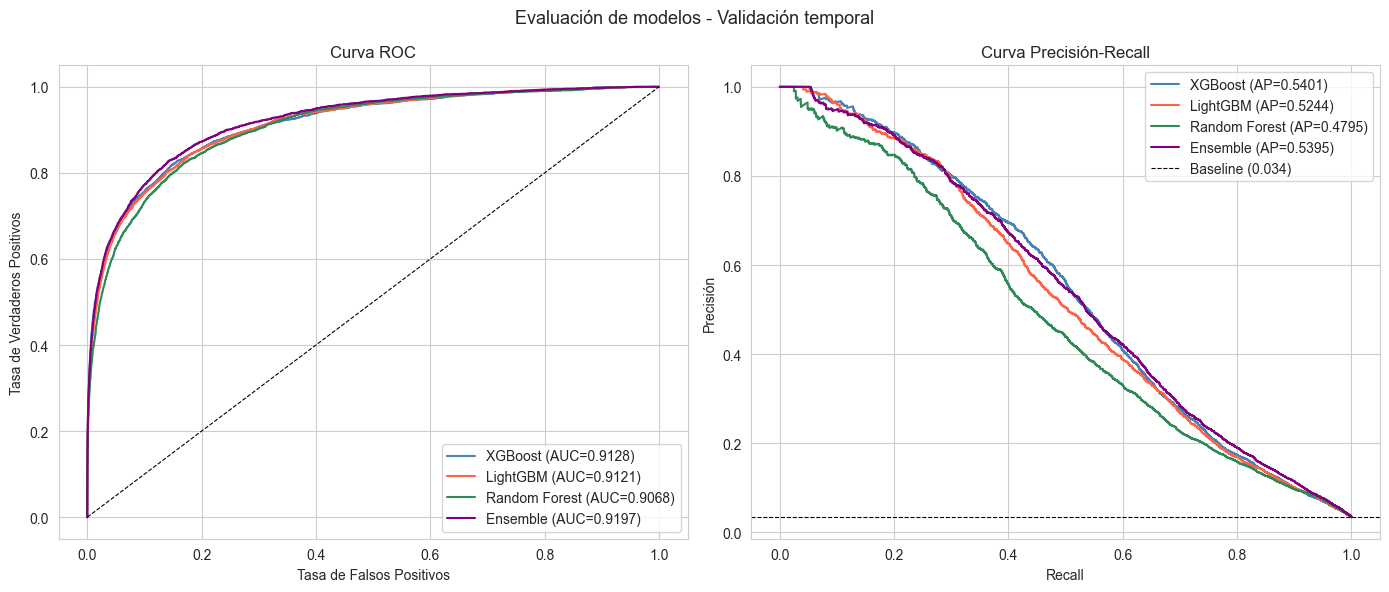

In [84]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models_preds = [
    ('XGBoost',       xgb_pred,                                    'steelblue'),
    ('LightGBM',      lgb_pred,                                    'tomato'),
    ('Random Forest', rf_pred,                                     'seagreen'),
    ('Ensemble',      0.4*xgb_pred + 0.3*lgb_pred + 0.3*rf_pred,  'purple'),  # añadido
]

for name, pred, color in models_preds:
    fpr, tpr, _ = roc_curve(y_val, pred)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, label=f'{name} (AUC={roc_auc:.4f})')

    prec, rec, _ = precision_recall_curve(y_val, pred)
    ap = average_precision_score(y_val, pred)
    axes[1].plot(rec, prec, color=color, label=f'{name} (AP={ap:.4f})')

axes[0].plot([0,1], [0,1], 'k--', linewidth=0.8)
axes[0].set_title('Curva ROC')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].legend()

baseline_pr = y_val.mean()
axes[1].axhline(baseline_pr, color='k', linestyle='--', linewidth=0.8,
                label=f'Baseline ({baseline_pr:.3f})')
axes[1].set_title('Curva Precisión-Recall')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precisión')
axes[1].legend()

plt.suptitle('Evaluación de modelos - Validación temporal', fontsize=13)
plt.tight_layout()
plt.show()

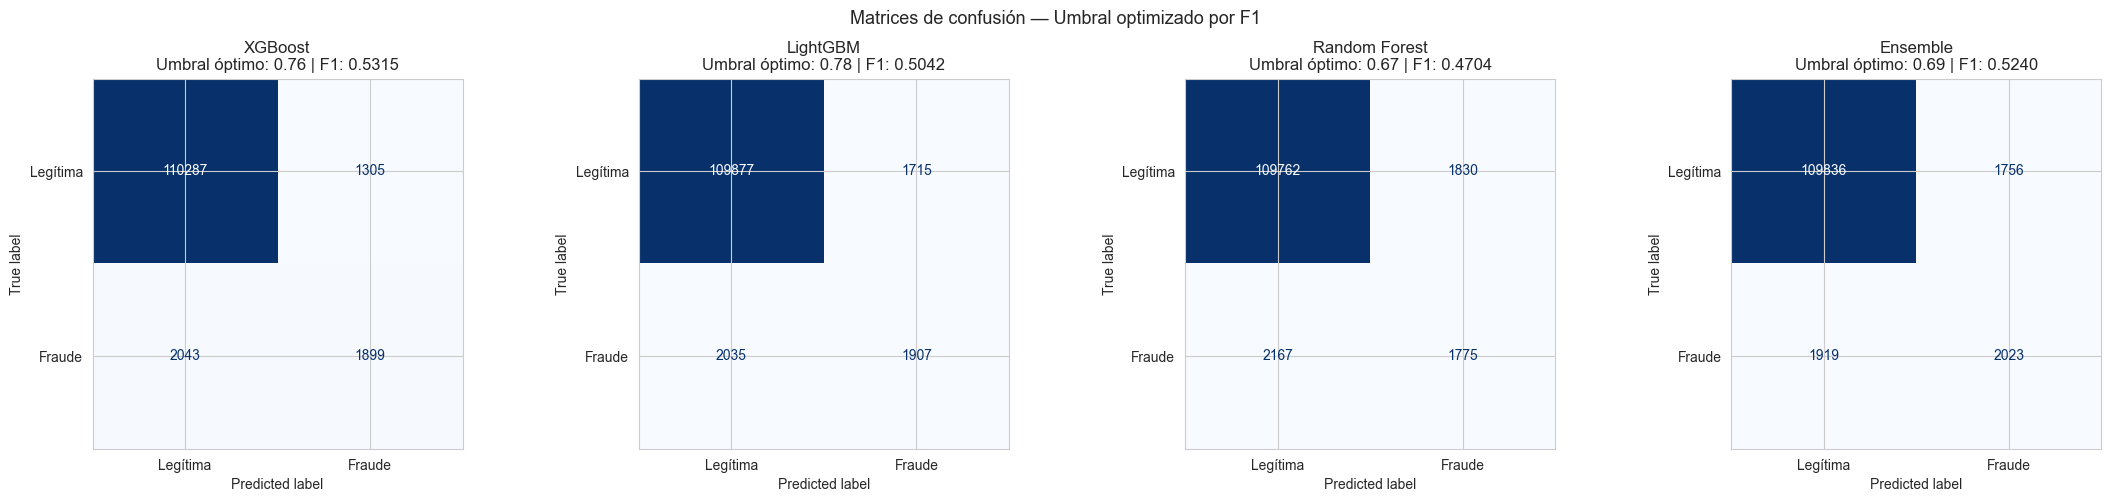

In [ ]:
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay

def find_best_threshold(y_true, y_prob):
    thresholds = np.arange(0.05, 0.95, 0.01)
    f1s = [f1_score(y_true, y_prob >= t, zero_division=0) for t in thresholds]
    best_t = thresholds[np.argmax(f1s)]
    return best_t, max(f1s)

ensemble_pred = 0.4*xgb_pred + 0.3*lgb_pred + 0.3*rf_pred  

models_preds = [
    ('XGBoost',       xgb_pred,      'steelblue'),
    ('LightGBM',      lgb_pred,      'tomato'),
    ('Random Forest', rf_pred,       'seagreen'),
    ('Ensemble',      ensemble_pred, 'purple'),   
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))  

for ax, (name, pred, color) in zip(axes.flat, models_preds):
    best_t, best_f1 = find_best_threshold(y_val, pred)
    y_pred_bin = (pred >= best_t).astype(int)
    cm = confusion_matrix(y_val, y_pred_bin)

    disp = ConfusionMatrixDisplay(cm, display_labels=['Legítima', 'Fraude'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nUmbral óptimo: {best_t:.2f} | F1: {best_f1:.4f}')

plt.suptitle('Matrices de confusión — Umbral optimizado por F1', fontsize=13)
plt.tight_layout()
plt.show()

Top 20 features del ensamble:


,feature,importance
0,TransactionAmt,92.409040
1,C2,82.814509
2,D1_norm,69.606061
3,Transaction_day,63.904659
4,P_emaildomain_FE,55.203676
5,addr1_FE,52.804027
6,card2_FE,51.002446
7,D2,48.905274
8,D15_norm,46.504039
9,D15,45.003146


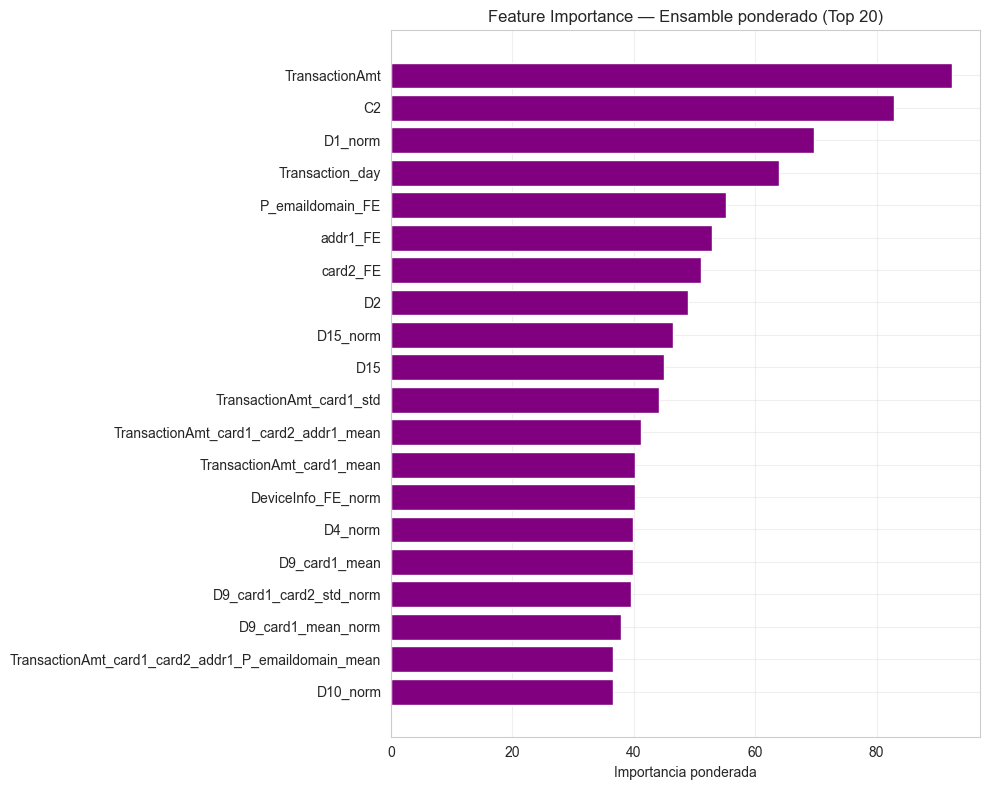

In [110]:
feature_names = list(X_train.columns)

w_xgb, w_lgb, w_rf = 0.4, 0.3, 0.3

#ponderando feature importance
ensemble_importance = (
    w_xgb * pd.Series(xgb_model.feature_importances_, index=feature_names) +
    w_lgb * pd.Series(lgb_model.feature_importances_, index=feature_names) +
    w_rf  * pd.Series(rf_model.feature_importances_,  index=feature_names)
)

top20 = ensemble_importance.nlargest(20)

top20_df = top20.reset_index()
top20_df.columns = ['feature', 'importance']
print("Top 20 features del ensamble:")
display(top20_df)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top20.index[::-1], top20.values[::-1], color='purple')
ax.set_title('Feature Importance — Ensamble ponderado (Top 20)')
ax.set_xlabel('Importancia ponderada')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

TOP 20
- TransactionAmt - monto de la transacción, fraudes tienden a tener montos atípicos.
- C2 - contador de Vesta (cuántas tarjetas están asociadas a la misma dirección). Alto C2 = señal de fraude.
- D1_norm - días desde la última transacción, normalizado por día, validando que el D-normalization funcionó.
- Transaction_day - el día en el tiempo del dataset. Los patrones de fraude cambian con el tiempo.
- P_emaildomain_FE - frecuencia del dominio de correo del comprador. Dominios raros = más riesgo.
- addr1_FE - frecuencia de la dirección de facturación. Direcciones inusuales = señal.
- card2_FE - frecuencia del segundo identificador de tarjeta.
- D2 - días desde la última transacción con esa tarjeta específica.
- D15_norm y D15 - días desde el último cambio de dirección, original y normalizado. Aparecen ambos, lo que sugiere que la versión normalizada añade señal independiente.
- TransactionAmt_card1_std y _mean — desviación estándar y media del monto por tarjeta. 
- TransactionAmt_card1_card2_addr1_mean - media del monto para el UID jerárquico completo. 
- DeviceInfo_FE_norm - frecuencia del dispositivo, normalizada.
- D4_norm, D9_norm, D10_norm - más D-columns normalizadas. 
- D9_card1_mean, D9_card1_card2_std_norm, D9_card1_mean_norm - agregaciones de D9 por grupo de tarjeta. 
- TransactionAmt_card1_card2_addr1_P_emaildomain_mean - media del monto para el UID de 4 niveles completo.

c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


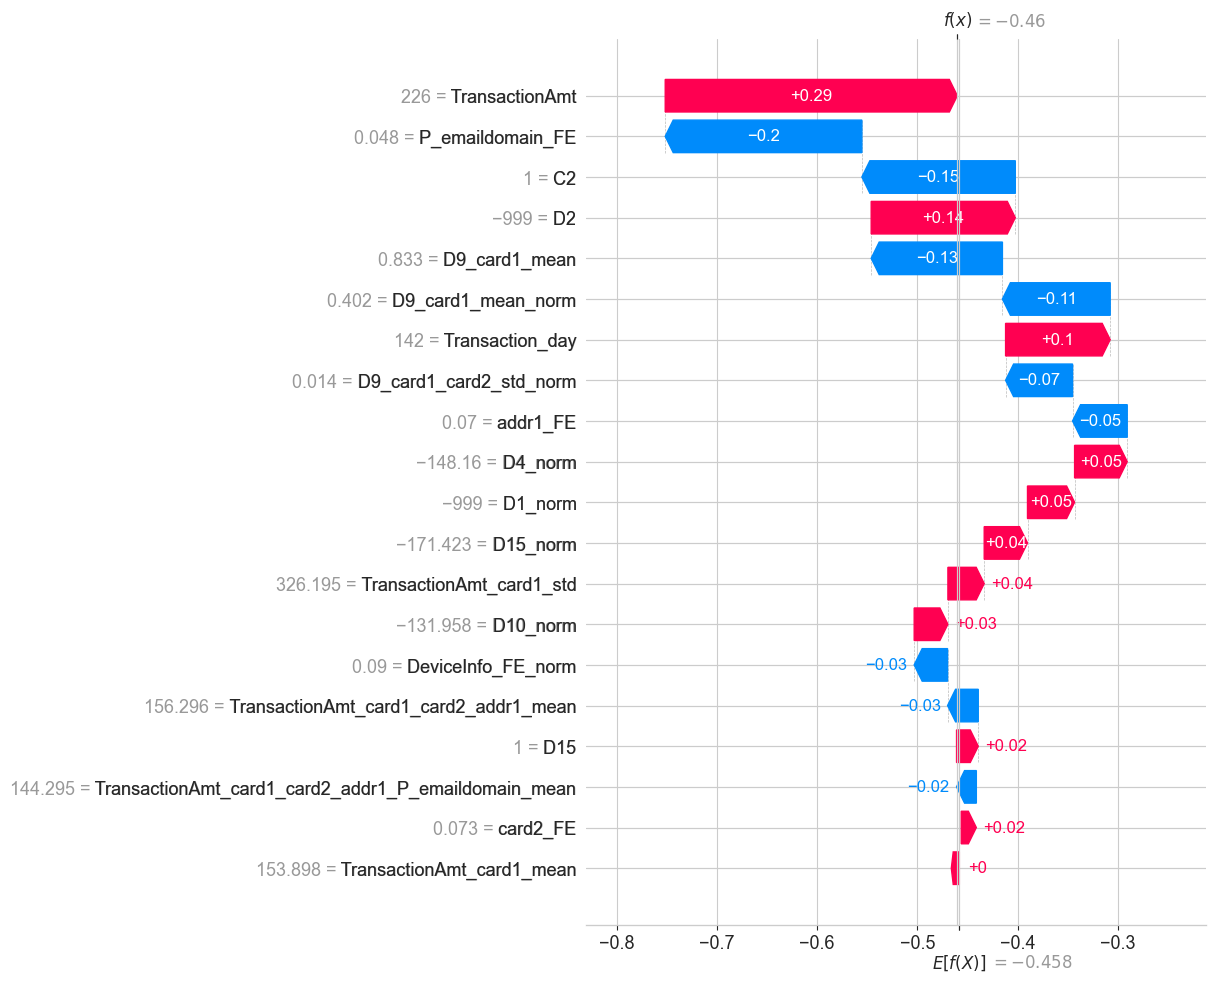

In [112]:
import shap

top20_features = top20_df['feature'].tolist()
explainer_xgb = shap.TreeExplainer(xgb_model)
explainer_lgb = shap.TreeExplainer(lgb_model)
explainer_rf  = shap.TreeExplainer(rf_model)

fraud_idx = X_val.index[y_val.loc[X_val.index] == 1][0]
sample    = X_val.loc[[fraud_idx]]
sample_rf = imputer.transform(sample)

sv_xgb = explainer_xgb.shap_values(sample)[0]
sv_lgb = explainer_lgb.shap_values(sample)[0]
sv_rf  = explainer_rf.shap_values(sample_rf)[0]
if sv_rf.ndim == 2:
    sv_rf = sv_rf[:, 1]

sv_weighted = w_xgb * sv_xgb + w_lgb * sv_lgb + w_rf * sv_rf

rf_base = explainer_rf.expected_value
if hasattr(rf_base, '__len__'):
    rf_base = rf_base[1]
base_weighted = (
    w_xgb * explainer_xgb.expected_value +
    w_lgb * explainer_lgb.expected_value +
    w_rf  * float(rf_base)
)

top20_idx = [feature_names.index(f) for f in top20_features]

shap.waterfall_plot(
    shap.Explanation(
        values        = sv_weighted[top20_idx],
        base_values   = base_weighted,
        data          = sample.iloc[0][top20_features].values,
        feature_names = top20_features
    ),
    max_display=len(top20_features)
)



### 7. Conclusión

In [95]:
results = pd.DataFrame({
    'Modelo': ['XGBoost', 'LightGBM', 'Random Forest', 'Ensemble'],
    'AUC-ROC': [xgb_auc, lgb_auc, rf_auc, 
                roc_auc_score(y_val, ensemble_pred)],
    'AP': [
        average_precision_score(y_val, xgb_pred),
        average_precision_score(y_val, lgb_pred),
        average_precision_score(y_val, rf_pred),
        average_precision_score(y_val, ensemble_pred)
    ],
    'F1 óptimo': [
        find_best_threshold(y_val, xgb_pred)[1],
        find_best_threshold(y_val, lgb_pred)[1],
        find_best_threshold(y_val, rf_pred)[1],
        find_best_threshold(y_val, ensemble_pred)[1]
    ],
    'Umbral óptimo': [
        find_best_threshold(y_val, xgb_pred)[0],
        find_best_threshold(y_val, lgb_pred)[0],
        find_best_threshold(y_val, rf_pred)[0],
        find_best_threshold(y_val, ensemble_pred)[0]
    ]
}).set_index('Modelo').round(4)

display(results.style
    .highlight_max(color='green')
    .set_caption('Comparación final de modelos - Validación temporal'))

,AUC-ROC,AP,F1 óptimo,Umbral óptimo
Modelo,,,,
XGBoost,0.912800,0.540100,0.531500,0.760000
LightGBM,0.912100,0.524400,0.504200,0.780000
Random Forest,0.906800,0.479500,0.470400,0.670000
Ensemble,0.919700,0.539500,0.524000,0.690000


Los cuatro modelos alcanzan un AUC-ROC superior a 0.90, lo que refleja una capacidad sólida para 
distinguir transacciones de fraude en un dataset totalmente desbalanceado. XGBoost y LightGBM 
obtienen resultados prácticamente idénticos como modelos individuales (0.9128 y 0.9121), mientras 
que Random Forest queda ligeramente por debajo (0.9068). El ensamble ponderado supera a todos los 
modelos individuales con un AUC de ~92% , confirmando que la combinación de modelos diversos 
captura patrones complementarios. En términos de F1, XGBoost es el mejor modelo individual (0.531 
con umbral 0.76), lo que indica que el modelo requiere alta confianza antes de clasificar una 
transacción como fraude, comportamiento esperado dado el costo asimétrico entre falsos positivos 
y falsos negativos para esta actividad.

### Exportación de modelos

In [91]:
import joblib
import json
import os

os.makedirs('model_export', exist_ok=True)

joblib.dump(xgb_model, 'model_export/xgb_model.pkl')
joblib.dump(lgb_model, 'model_export/lgb_model.pkl')
joblib.dump(rf_model,  'model_export/rf_model.pkl')
joblib.dump(imputer,   'model_export/imputer.pkl')  

metadata = {
    'ensemble_weights': {'xgb': 0.4, 'lgb': 0.3, 'rf': 0.3},
    'feature_names': list(X_train.columns),
    'top20_features': top20_df['feature'].tolist(),
    'optimal_threshold': float(find_best_threshold(y_val, ensemble_pred)[0]),
    'val_auc': float(roc_auc_score(y_val, ensemble_pred)),
}

with open('model_export/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("exportado en model_export/")
print(f"  xgb_model.pkl")
print(f"  lgb_model.pkl")
print(f"  rf_model.pkl")
print(f"  imputer.pkl")
print(f"  metadata.json")

exportado en model_export/
  xgb_model.pkl
  lgb_model.pkl
  rf_model.pkl
  imputer.pkl
  metadata.json
